# **Flow 2: Eksplorasi & Validasi Data (EDA)**



## **2.1. Analisis Pola Rush Hour**

**Teknik Code:** `groupby('timestamp').mean()` + line plot

**Cara Kerja:** Menghitung rata-rata kecepatan di seluruh jaringan per satuan waktu, lalu memplot tren sepanjang minggu untuk mengecek apakah pola jam sibuk pagi/sore benar-benar terlihat.

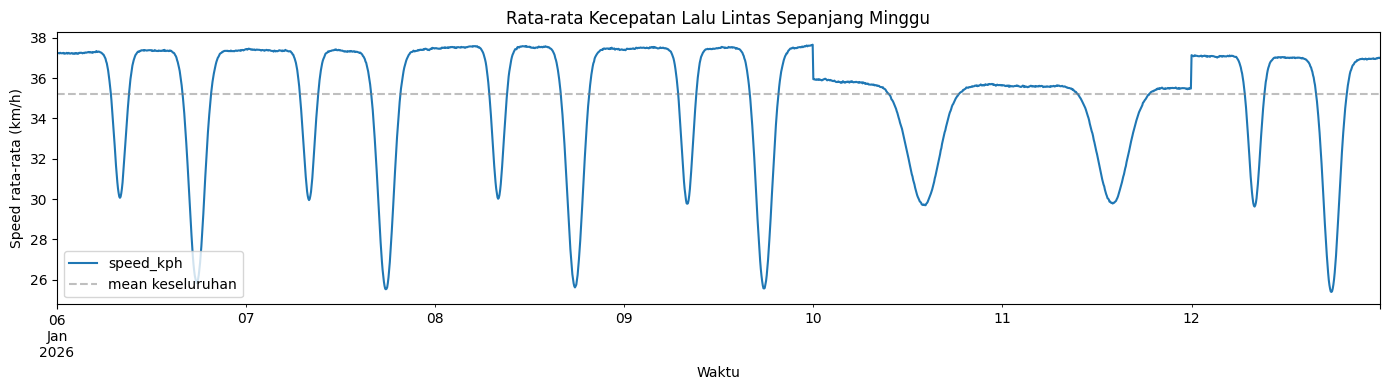

In [ ]:
import matplotlib.pyplot as plt

# ===== 1. Cek pola rush hour =====
fig, ax = plt.subplots(figsize=(14, 4))
df_speed.groupby('timestamp')['speed_kph'].mean().plot(ax=ax)
ax.set_title('Rata-rata Kecepatan Lalu Lintas Sepanjang Minggu')
ax.set_xlabel('Waktu')
ax.set_ylabel('Speed rata-rata (km/h)')
ax.axhline(df_speed['speed_kph'].mean(), color='gray', linestyle='--', alpha=0.5, label='mean keseluruhan')
ax.legend()
plt.tight_layout()
plt.savefig('rush_hour_pattern_check.png', dpi=150)
plt.show()

In [ ]:
# Cek angka spesifik: bandingkan jam sibuk vs non-sibuk
df_speed['hour'] = df_speed['timestamp'].dt.hour
df_speed['dayofweek'] = df_speed['timestamp'].dt.dayofweek
hourly_avg = df_speed.groupby('hour')['speed_kph'].mean()
print("Speed rata-rata per jam:")
print(hourly_avg)
print(f"\nJam tersibuk (speed terendah): {hourly_avg.idxmin()}:00 -> {hourly_avg.min():.1f} km/h")
print(f"Jam paling lancar (speed tertinggi): {hourly_avg.idxmax()}:00 -> {hourly_avg.max():.1f} km/h")

Speed rata-rata per jam:
hour
0     36.886847
1     36.888697
2     36.878107
3     36.868016
4     36.881991
5     36.849173
6     36.097995
7     32.960273
8     32.660023
9     35.819014
10    36.487238
11    36.151243
12    35.632212
13    35.250715
14    35.183683
15    34.876435
16    32.392088
17    28.749015
18    30.325237
19    34.718989
20    36.516180
21    36.809781
22    36.839940
23    36.850121
Name: speed_kph, dtype: float64

Jam tersibuk (speed terendah): 17:00 -> 28.7 km/h
Jam paling lancar (speed tertinggi): 1:00 -> 36.9 km/h


In [ ]:
weekday_avg = df_speed[df_speed['dayofweek'] < 5]['speed_kph'].mean()
weekend_avg = df_speed[df_speed['dayofweek'] >= 5]['speed_kph'].mean()
print(f"Weekday avg: {weekday_avg:.1f} km/h")
print(f"Weekend avg: {weekend_avg:.1f} km/h")
# Weekend harus lebih tinggi dari weekday

Weekday avg: 35.5 km/h
Weekend avg: 34.5 km/h


## **2.2 Cek Variansi & Korelasi antar Edge**

**Teknik Code:** `groupby(['u','v','k']).std()` + `DataFrame.corr()`

**Cara Kerja:** Mengukur seberapa besar variasi kecepatan tiap ruas jalan sepanjang waktu, dan mengecek korelasi antara variansi tersebut dengan kecepatan dasar (free flow) tiap ruas.

In [ ]:
edge_variance = df_speed.groupby(['u', 'v', 'k'])['speed_kph'].std()
print(edge_variance.describe())
# Kalau std antar edge kecil semua, berarti semua edge "seragam" ikut pola global

count    5783.000000
mean        5.837987
std         1.395716
min         3.156069
25%         4.879876
50%         5.650655
75%         6.496017
max        14.410454
Name: speed_kph, dtype: float64


In [ ]:
edge_freeflow = {(u,v,k): data['speed_kph'] for u,v,k,data in edges}
df_check = edge_variance.reset_index()
df_check['free_flow'] = df_check.apply(lambda r: edge_freeflow[(r['u'], r['v'], r['k'])], axis=1)
print(df_check[['speed_kph', 'free_flow']].corr())

           speed_kph  free_flow
speed_kph   1.000000   0.679691
free_flow   0.679691   1.000000


## **2.3 Data Quality Check Menyeluruh + Cross-Correlation Spasial**

**Teknik Code:** `duplicated(),` `describe(),` `pivot_table(),` time-lagged `.shift(lag)` correlation

**Cara Kerja:** Mengecek duplikasi data dan rentang nilai kecepatan yang tidak wajar, membandingkan rata-rata weekday vs weekend, lalu menghitung korelasi antar-edge utama dengan pergeseran waktu (lag) untuk membuktikan adanya propagasi kemacetan (bukan hanya korelasi sesaat).

=== Data Quality Check ===
Duplicate rows: 0
Speed range: 10.3 - 80.0 km/h
Negative/zero speed: 0
count    1.165853e+07
mean     3.523221e+01
std      8.285363e+00
min      1.032511e+01
25%      2.981896e+01
50%      3.504755e+01
75%      3.934657e+01
max      8.000000e+01
Name: speed_kph, dtype: float64

Weekday avg: 35.5 km/h | Weekend avg: 34.5 km/h


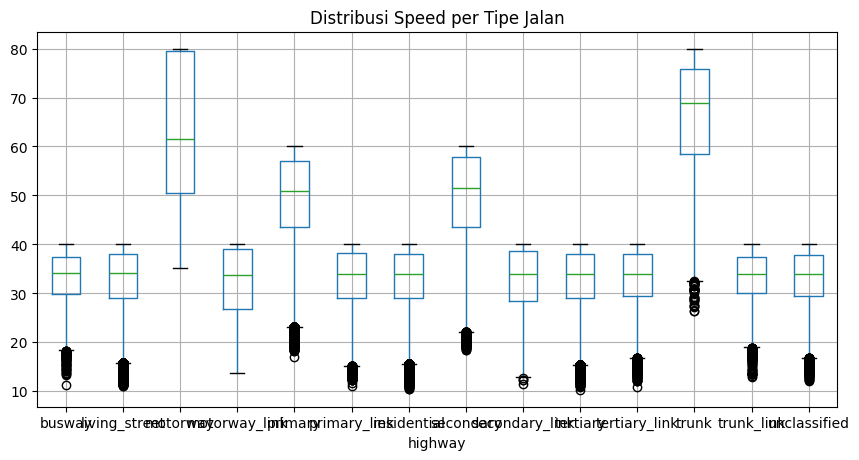


=== Cross-correlation antar edge utama ===
u                       29938969              29938988   103287924  103292425
v                      4488259599 5227846481 191578995  2350594245 309684894 
k                               0          0          0          0          0
u         v          k                                                       
29938969  4488259599 0   1.000000   0.310724  -0.130108   0.016363   0.386461
          5227846481 0   0.310724   1.000000  -0.364811   0.156962   0.257627
29938988  191578995  0  -0.130108  -0.364811   1.000000   0.311624   0.216841
103287924 2350594245 0   0.016363   0.156962   0.311624   1.000000   0.313581
103292425 309684894  0   0.386461   0.257627   0.216841   0.313581   1.000000


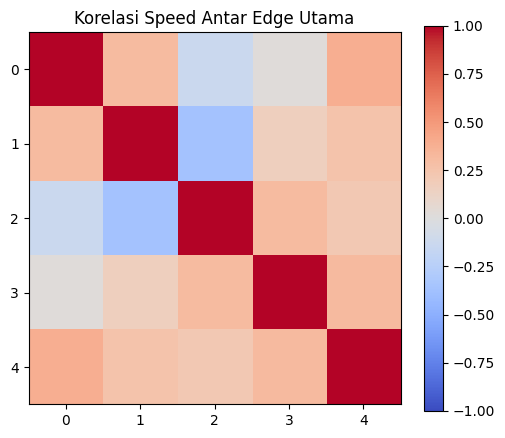

Lag 0 menit: korelasi = 0.311
Lag 5 menit: korelasi = 0.308
Lag 10 menit: korelasi = 0.305
Lag 15 menit: korelasi = 0.301


In [ ]:
# ===== 1. Basic data quality check =====
print("=== Data Quality Check ===")
print(f"Duplicate rows: {df_speed.duplicated(subset=['u','v','k','timestamp']).sum()}")
print(f"Speed range: {df_speed['speed_kph'].min():.1f} - {df_speed['speed_kph'].max():.1f} km/h")
print(f"Negative/zero speed: {(df_speed['speed_kph'] <= 0).sum()}")
print(df_speed['speed_kph'].describe())

# ===== 2. Weekday vs Weekend =====
weekday_avg = df_speed[df_speed['dayofweek'] < 5]['speed_kph'].mean()
weekend_avg = df_speed[df_speed['dayofweek'] >= 5]['speed_kph'].mean()
print(f"\nWeekday avg: {weekday_avg:.1f} km/h | Weekend avg: {weekend_avg:.1f} km/h")

# ===== 3. Speed distribution by road type =====
import matplotlib.pyplot as plt

edge_hwy = {}
for u, v, k, data in G.edges(keys=True, data=True):
    hwy = data.get('highway', 'unknown')
    hwy = hwy[0] if isinstance(hwy, list) else hwy
    edge_hwy[(u, v, k)] = hwy

df_speed['highway'] = df_speed.apply(lambda r: edge_hwy.get((r['u'], r['v'], r['k']), 'unknown'), axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
df_speed.boxplot(column='speed_kph', by='highway', ax=ax)
plt.suptitle('')
ax.set_title('Distribusi Speed per Tipe Jalan')
plt.savefig('speed_by_roadtype.png', dpi=150)
plt.show()

# ===== 4. Spatial cross-correlation (PALING PENTING untuk judul project) =====
# Pilih beberapa edge kunci di koridor utama (misal top 5 edge dengan traffic tertinggi/motorway)
main_edges = df_speed[df_speed['highway'].isin(['primary', 'trunk', 'motorway'])][['u','v','k']].drop_duplicates().head(5)

pivot_main = df_speed[df_speed.set_index(['u','v','k']).index.isin(
    pd.MultiIndex.from_frame(main_edges))].pivot_table(
    index='timestamp', columns=['u','v','k'], values='speed_kph')

corr_matrix = pivot_main.corr()
print("\n=== Cross-correlation antar edge utama ===")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Korelasi Speed Antar Edge Utama')
plt.colorbar(im)
plt.savefig('spatial_correlation.png', dpi=150)
plt.show()

# ===== 5. Time-lagged correlation (bukti propagasi, bukan cuma korelasi serentak) =====
edge_a = pivot_main.columns[0]
edge_b = pivot_main.columns[1]
for lag in [0, 1, 2, 3]:  # lag dalam step 5-menit
    corr = pivot_main[edge_a].corr(pivot_main[edge_b].shift(lag))
    print(f"Lag {lag*5} menit: korelasi = {corr:.3f}")

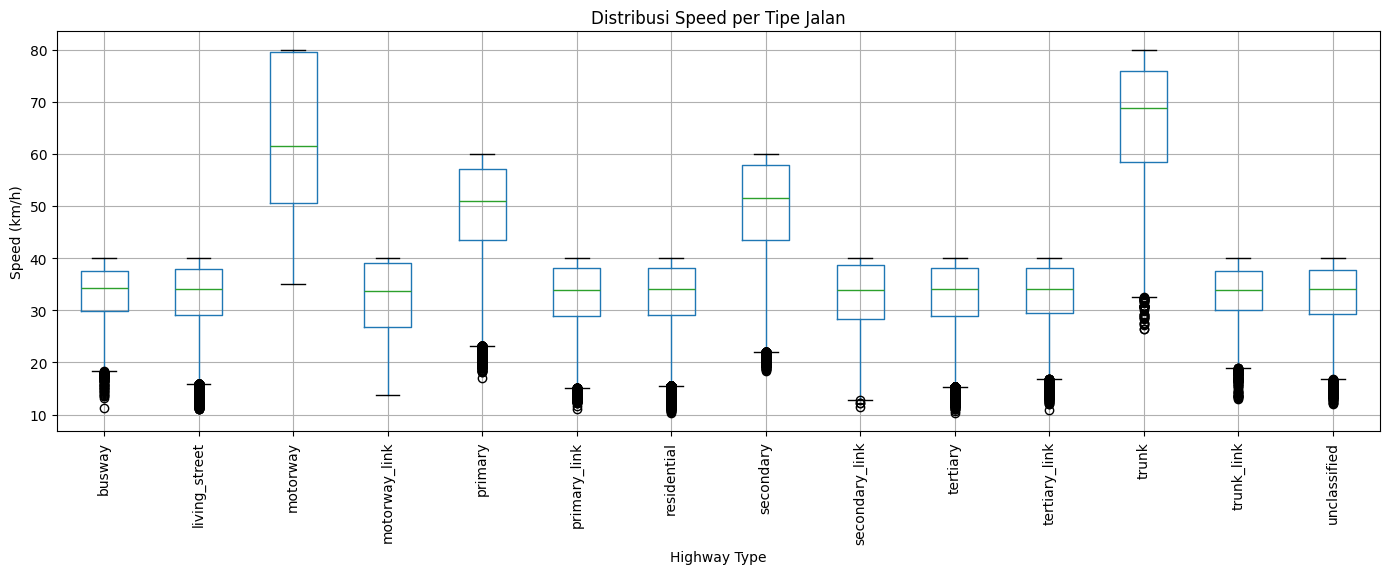

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
df_speed.boxplot(column='speed_kph', by='highway', ax=ax, rot=90)
plt.suptitle('')
ax.set_title('Distribusi Speed per Tipe Jalan')
ax.set_xlabel('Highway Type')
ax.set_ylabel('Speed (km/h)')
plt.tight_layout()
plt.savefig('speed_by_roadtype.png', dpi=150)
plt.show()

## **2.4 Distribusi Speed per Tipe Jalan**

**Teknik Code:** `DataFrame.boxplot()` + fungsi kustom `group_highway()`

**Cara Kerja:** Mengelompokkan tipe jalan (arteri utama, arteri sekunder, jalan lokal, dll.) lalu membuat boxplot distribusi kecepatan untuk tiap kelompok guna melihat karakteristik lalu lintas per jenis jalan.

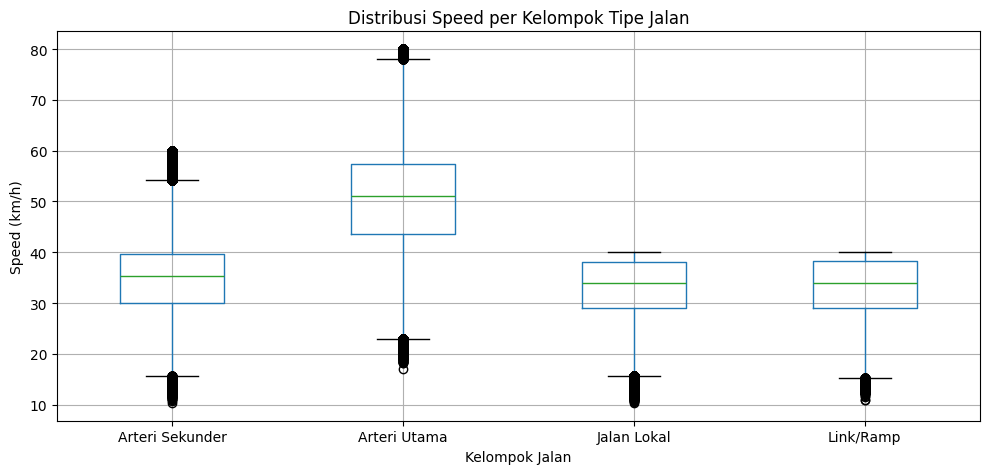

highway_group
Jalan Lokal        7945056
Arteri Sekunder    2302272
Arteri Utama       1090656
Link/Ramp           320544
Name: count, dtype: int64


In [ ]:
def group_highway(hwy):
    if hwy in ['motorway', 'trunk', 'primary']:
        return 'Arteri Utama'
    elif hwy in ['secondary', 'tertiary']:
        return 'Arteri Sekunder'
    elif hwy in ['residential', 'living_street', 'unclassified', 'busway']:
        return 'Jalan Lokal'
    elif '_link' in str(hwy):
        return 'Link/Ramp'
    else:
        return 'Lainnya'

df_speed['highway_group'] = df_speed['highway'].apply(group_highway)

fig, ax = plt.subplots(figsize=(10, 5))
df_speed.boxplot(column='speed_kph', by='highway_group', ax=ax)
plt.suptitle('')
ax.set_title('Distribusi Speed per Kelompok Tipe Jalan')
ax.set_xlabel('Kelompok Jalan')
ax.set_ylabel('Speed (km/h)')
plt.tight_layout()
plt.savefig('speed_by_roadtype_grouped.png', dpi=150)
plt.show()

print(df_speed['highway_group'].value_counts())

## **2.5 Penyimpanan Data Final**

**Teknik Code:** `pickle.dump()` (graf) + `to_parquet()` (data speed) + dictionary metadata

**Cara Kerja:** Menyimpan graf jalan final (dengan atribut lengkap), data kecepatan final, dan metadata ringkas (jumlah node/edge, rentang waktu) ke disk agar tahap modeling berikutnya tidak perlu mengulang parsing dari awal.

In [ ]:
import pickle
import os

# ===== 2. Simpan G (graph dengan atribut speed & capacity) =====
with open('sudirman_thamrin_graph_final.pkl', 'wb') as f:
    pickle.dump(G, f)

# ===== 3. Pastikan df_speed final (dengan kolom hour/dayofweek) tersimpan ulang =====
df_speed.to_parquet('synthetic_traffic_speed.parquet', index=False)

# ===== 4. Simpan metadata kecil biar Notebook 3 gak perlu re-parse =====
metadata = {
    'n_nodes': G.number_of_nodes(),
    'n_edges': G.number_of_edges(),
    'node_list': list(G.nodes()),
    'edge_list': [(u, v, k) for u, v, k in G.edges(keys=True)],
    'time_range': (df_speed['timestamp'].min(), df_speed['timestamp'].max()),
    'time_resolution': '5min',
    'center_point': (-6.1944, 106.8229),
}
with open('metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

# ===== 5. Verifikasi ukuran file =====
for fname in ['sudirman_thamrin_graph_final.pkl', 'synthetic_traffic_speed.parquet', 'metadata.pkl']:
    size_mb = os.path.getsize(fname) / (1024 * 1024)
    print(f"{fname}: {size_mb:.2f} MB")

sudirman_thamrin_graph_final.pkl: 1.39 MB
synthetic_traffic_speed.parquet: 88.32 MB
metadata.pkl: 0.10 MB
